In [ ]:
#libraries
#!pip install fastparquet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys



## Load Dataset

If not installed run scripts/download_data.py then unpack the zipped file.

*train_landmark_files/[participant_id]/[sequence_id].parquet*


## Parquet format

frame - The frame number in the raw video. 

row_id - A unique identifier for the row. 

type - The type of landmark. One of ['face', 'left_hand', 'pose', 'right_hand']. 

landmark_index - The landmark index number. Details of the hand landmark locations can be found here. 

[x/y/z] - The normalized spatial coordinates of the landmark. These are the only columns that will be provided to your submitted model for inference. **The MediaPipe model is not fully trained to predict depth so you may wish to ignore the z values.**



In [17]:
#read in one parquet file
base_path = Path("..")
data_path = base_path / "data" / "asl-signs" / "train_landmark_files" / "2044" / "635217.parquet"
parquet_df = pd.read_parquet(data_path, engine = 'fastparquet')
parquet_df.head()
print(len(parquet_df.landmark_index))

3801


In [16]:
print(parquet_df.frame.value_counts())

frame
22    543
23    543
24    543
25    543
26    543
27    543
28    543
Name: count, dtype: int64


In [15]:
#read in another parquet file to compare
parquet_df = pd.read_parquet(data_path, engine = 'fastparquet')
parquet_df.head()
#print(len(parquet_df.landmark_index))
print(parquet_df.landmark_index.value_counts())

landmark_index
0      28
1      28
2      28
3      28
4      28
       ..
463     7
464     7
465     7
466     7
467     7
Name: count, Length: 468, dtype: int64


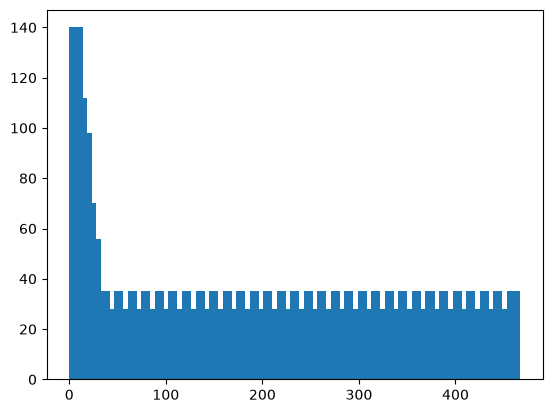

In [14]:
plt.hist(parquet_df.landmark_index,bins = 100)
plt.show()

## Train dataset dataframe

In [13]:
train_csv_path = base_path / "data" / "asl-signs" / "train.csv"
train_df = pd.read_csv(train_csv_path)
print(train_df.head())
print(train_df.info())

                                            path  participant_id  sequence_id  \
0  train_landmark_files/26734/1000035562.parquet           26734   1000035562   
1  train_landmark_files/28656/1000106739.parquet           28656   1000106739   
2   train_landmark_files/16069/100015657.parquet           16069    100015657   
3  train_landmark_files/25571/1000210073.parquet           25571   1000210073   
4  train_landmark_files/62590/1000240708.parquet           62590   1000240708   

    sign  
0   blow  
1   wait  
2  cloud  
3   bird  
4   owie  
<class 'pandas.DataFrame'>
RangeIndex: 94477 entries, 0 to 94476
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   path            94477 non-null  str  
 1   participant_id  94477 non-null  int64
 2   sequence_id     94477 non-null  int64
 3   sign            94477 non-null  str  
dtypes: int64(2), str(2)
memory usage: 2.9 MB
None


# Visualizing Key Frames

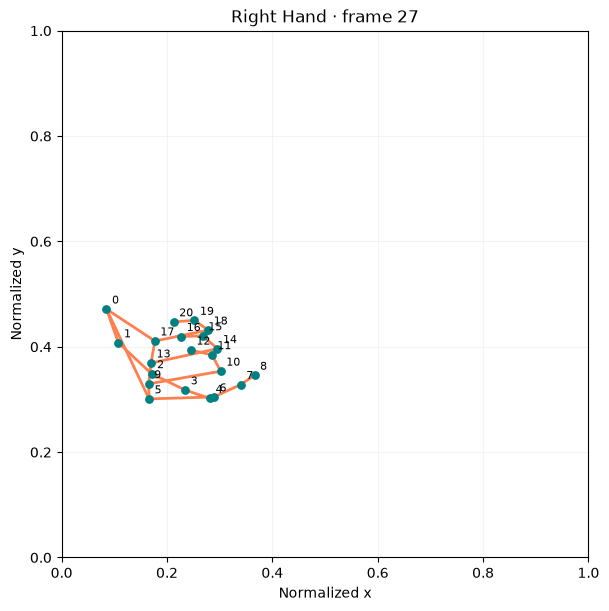

In [12]:
from src.visualization import plot_hand

hand_type = "right_hand"  
frame_ids = np.sort(parquet_df["frame"].unique())
frame_id = frame_ids[5]  


fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
plot_hand(ax, parquet_df, frame_id, hand_type, label_points=True)
plt.show()


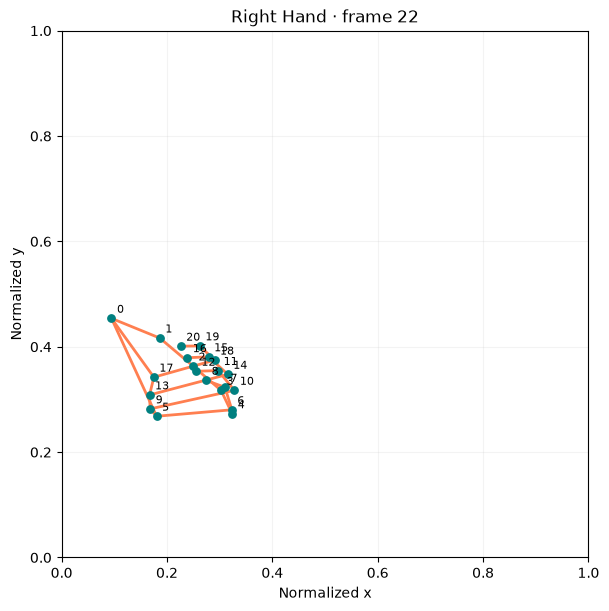

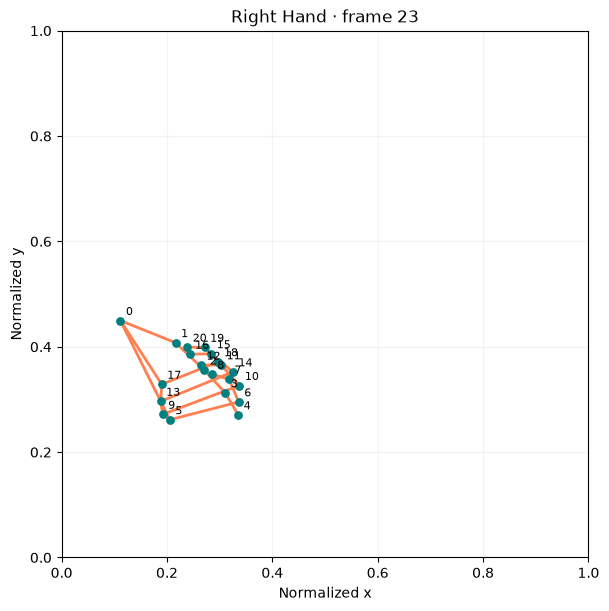

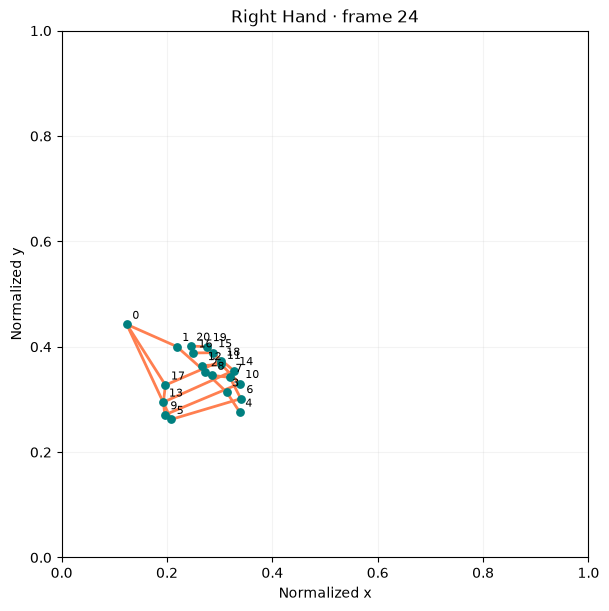

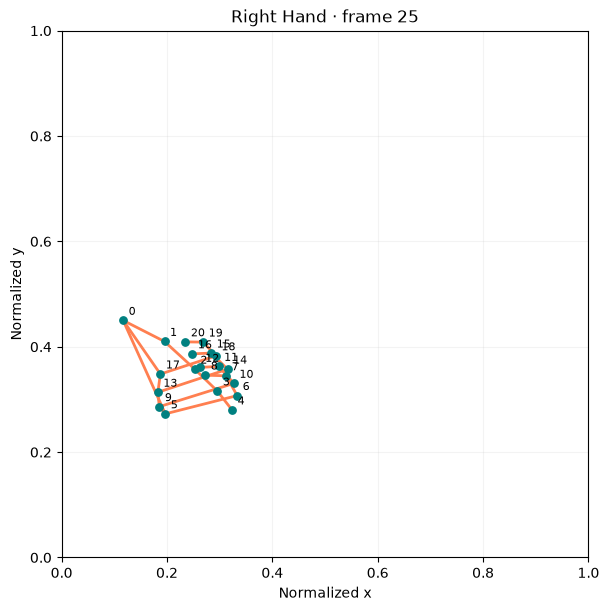

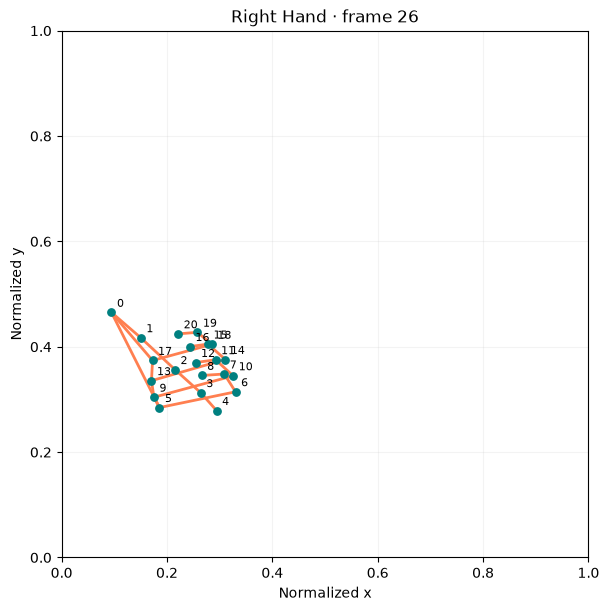

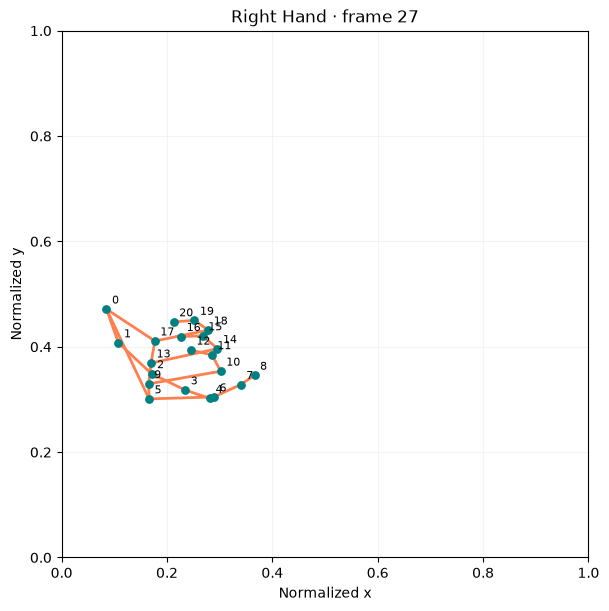

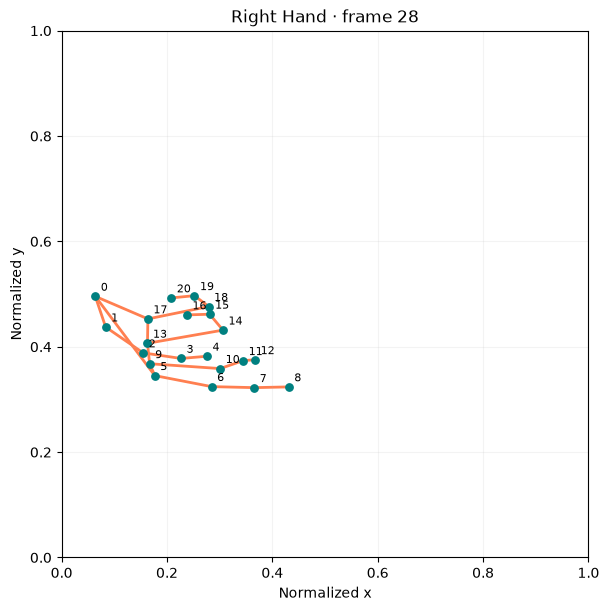

In [11]:
hand_type = "right_hand"  
frame_ids = np.sort(parquet_df["frame"].unique())

for frame_id in frame_ids:
    fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
    plot_hand(ax, parquet_df, frame_id, hand_type, label_points=True)
    plt.show()